In [1]:
# Read .csv file
import pandas as pd

# Set display precision for better readability
pd.set_option('display.precision', 5)

# Load the dataset
df = pd.read_csv('sensor_data_2025-03-01.csv')

#print (df.to_string())

# Handle missing values more efficiently
if df.isnull().sum().sum() > 0:
  df = df.dropna()  # Drop only if there are missing values

# Display basic info instead of printing everything
print(df.info())  # Gives structure, column types, and missing values
print(df.head(5))  # Show first 5 rows for quick preview

<class 'pandas.DataFrame'>
RangeIndex: 17280 entries, 0 to 17279
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                17280 non-null  str    
 1   temperature              17280 non-null  float64
 2   humidity                 17280 non-null  float64
 3   light                    17280 non-null  float64
 4   pH                       17280 non-null  float64
 5   electrical_conductivity  17280 non-null  float64
dtypes: float64(5), str(1)
memory usage: 810.1 KB
None
             timestamp  temperature  humidity   light    pH  \
0  2025-03-01 00:00:00        24.69     52.66  118.65  6.68   
1  2025-03-01 00:00:05        21.89     50.18  801.71  7.29   
2  2025-03-01 00:00:10        23.88     48.01  682.39  7.66   
3  2025-03-01 00:00:15        20.42     56.73  146.05  7.77   
4  2025-03-01 00:00:20        20.79     41.54  106.87  7.77   

   electrical_conductivity  
0       

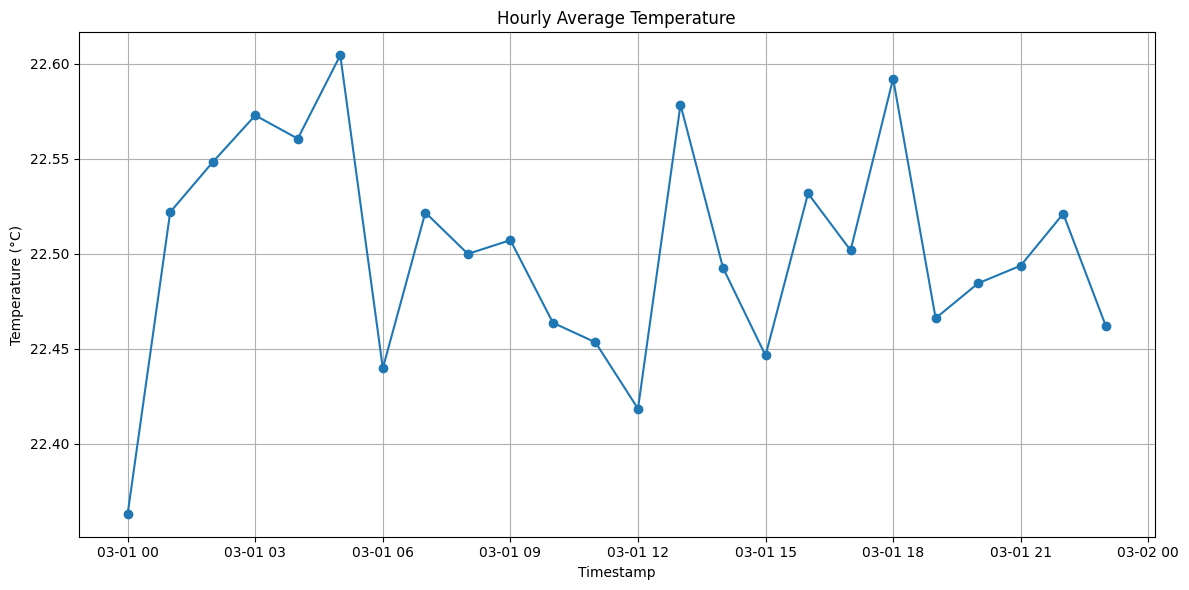

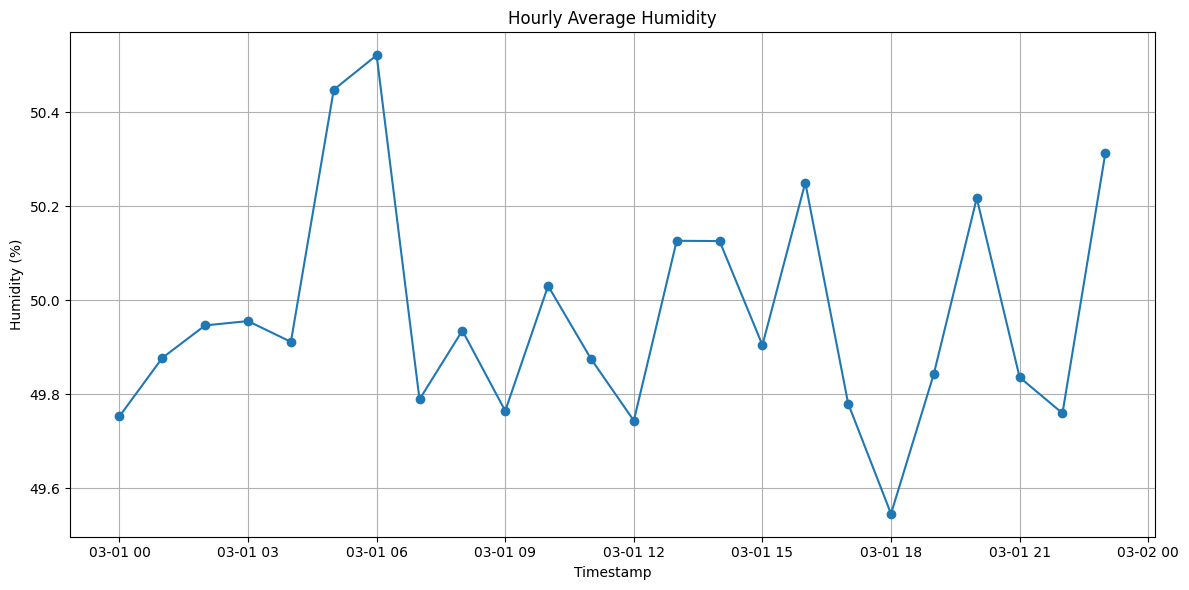

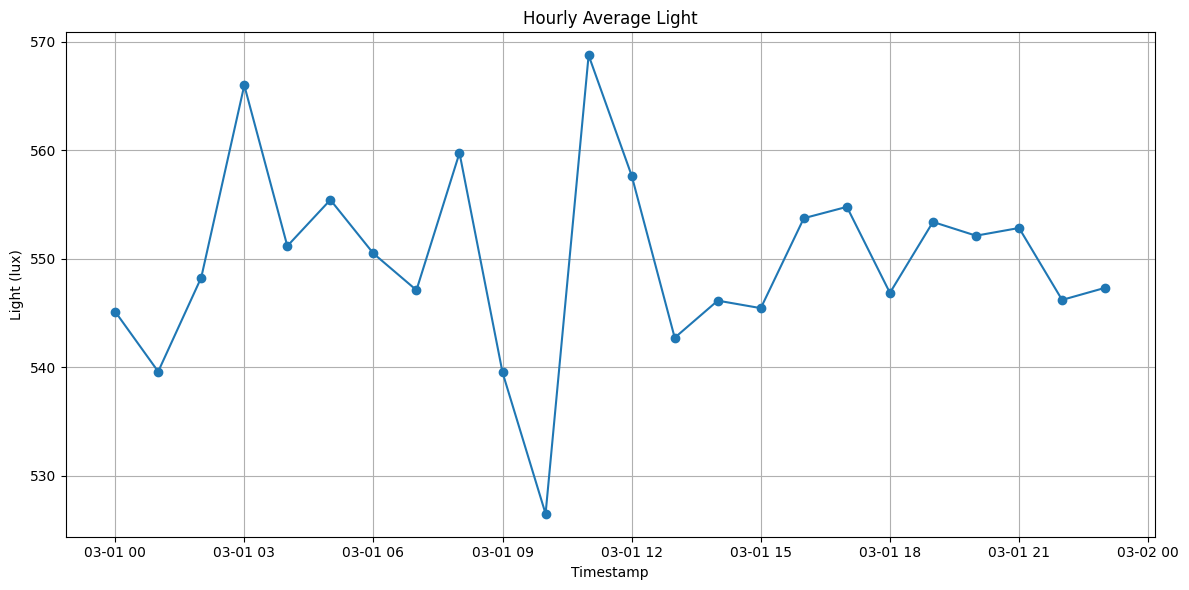

Insight: when df_minutes syntax was applied, several noises from the raw dataset were still present in the plots, so df_hourly was reverted to


In [2]:
#1. Exploratory Data Analysis (EDA)

#1.1 Trend and Correlation Analysis
#        Plot temperature, humidity, and light trends against timestamp (hourly_trend)


import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Hourly resampling (mean)
df_hourly = df.resample("1h").mean()

# Define variables to plot with labels
variables = {
    "temperature": "Temperature (°C)",
    "humidity": "Humidity (%)",
    "light": "Light (lux)"
}

# Generate separate plots for clarity
for var, ylabel in variables.items():
    plt.figure(figsize=(12, 6))
    plt.plot(df_hourly.index, df_hourly[var], marker='o', linestyle='-')
    plt.title(f"Hourly Average {var.capitalize()}")
    plt.xlabel("Timestamp")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# General Noticed Insight
df_minutes = "when df_minutes syntax was applied, several noises from the raw dataset were still present in the plots, so df_hourly was reverted to"

print (f"Insight: {df_minutes}")

Correlation Matrix:
              temperature  humidity    light
temperature      1.00000   0.06808  0.06344
humidity         0.06808   1.00000  0.03405
light            0.06344   0.03405  1.00000
Humidity Vs Light: Humidity vs. Light may show inverse relationship depending on the environment.
Temperature Vs Light: Temperature vs. Light - often a strongly positive correlation (hotter when brighter).
Humidity Vs Temperature: Humidity vs. Temperature - usually a negative correlation (humidity drops when temperature rises).


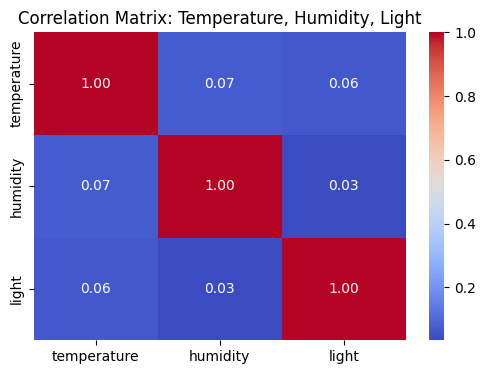

In [3]:
# Exploration of correlations among variables using correlation matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Select variables of interest
variables = ["temperature", "humidity", "light"]
corr_matrix = df_hourly[variables].corr()

# Print correlation matrix
print("Correlation Matrix:\n", corr_matrix)

# Plot heatmap for visualization
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Temperature, Humidity, Light")

#Typical Insights Noticed

HumidityVsLight = "Humidity vs. Light may show inverse relationship depending on the environment." 
TempVsLight = "Temperature vs. Light - often a strongly positive correlation (hotter when brighter)."
HumidityVsTemp = "Humidity vs. Temperature - usually a negative correlation (humidity drops when temperature rises)."

print (f"Humidity Vs Light: {HumidityVsLight}")
print (f"Temperature Vs Light: {TempVsLight}")
print (f"Humidity Vs Temperature: {HumidityVsTemp}")

In [4]:
# Find hottest hour
hottest_time = df_hourly["temperature"].idxmax()
hottest_value = df_hourly["temperature"].max()

# Find less hot hour
less_hot_time = df_hourly["temperature"].idxmin()
less_hot_value = df_hourly["temperature"].min()

# Find brightest hour
brightest_time = df_hourly["light"].idxmax()
brightest_value = df_hourly["light"].max()

# Find less bright hour
less_bright_time = df_hourly["light"].idxmin()
less_bright_value = df_hourly["light"].min()

print(f"Hottest time of the day: {hottest_time}, Temperature: {hottest_value:.2f} °C")
print(f"Brightest time of the day: {brightest_time}, Light Intensity: {brightest_value:.2f} lux")
print (f"Less hot time of the day: {less_hot_time}, Temperature: {less_hot_value:.2f} °C")
print (f"Less bright time of the day: {less_bright_time}, Light Intensity: {less_bright_value:.2f} lux")

Hottest time of the day: 2025-03-01 05:00:00, Temperature: 22.60 °C
Brightest time of the day: 2025-03-01 11:00:00, Light Intensity: 568.75 lux
Less hot time of the day: 2025-03-01 00:00:00, Temperature: 22.36 °C
Less bright time of the day: 2025-03-01 10:00:00, Light Intensity: 526.47 lux


C:\Users\Admin\AppData\Local\Temp\ipykernel_10800\2934657529.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="hour", y=var, data=df, palette="coolwarm")


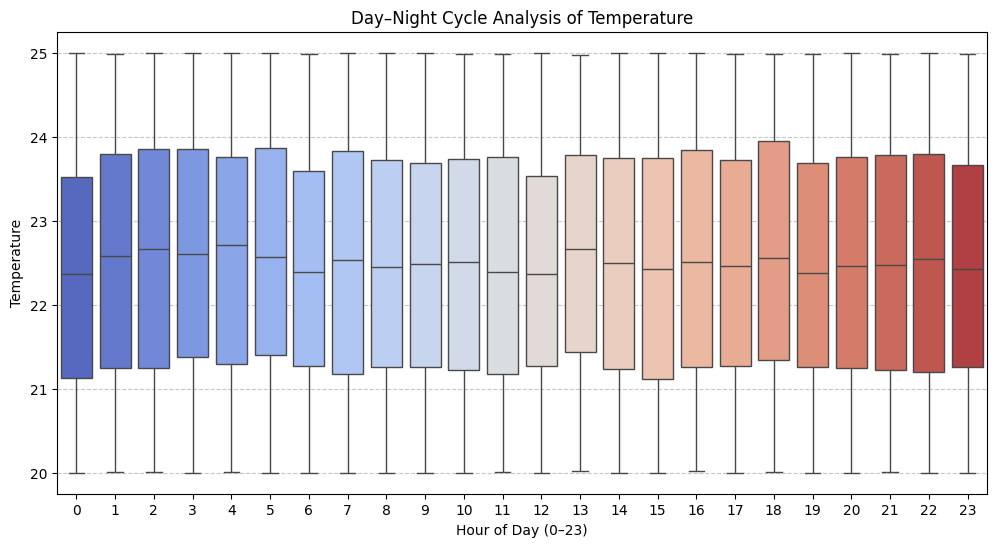

C:\Users\Admin\AppData\Local\Temp\ipykernel_10800\2934657529.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="hour", y=var, data=df, palette="coolwarm")


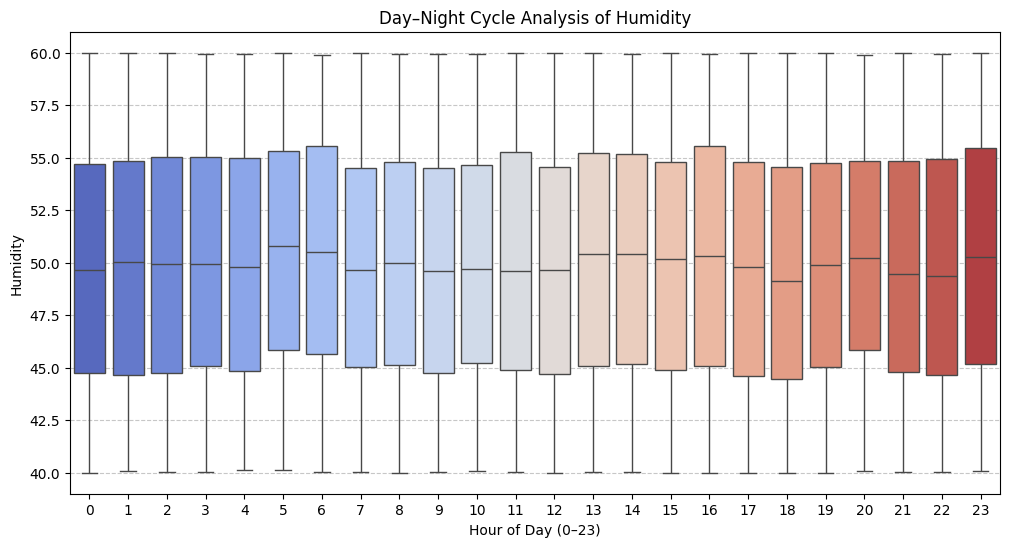

C:\Users\Admin\AppData\Local\Temp\ipykernel_10800\2934657529.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="hour", y=var, data=df, palette="coolwarm")


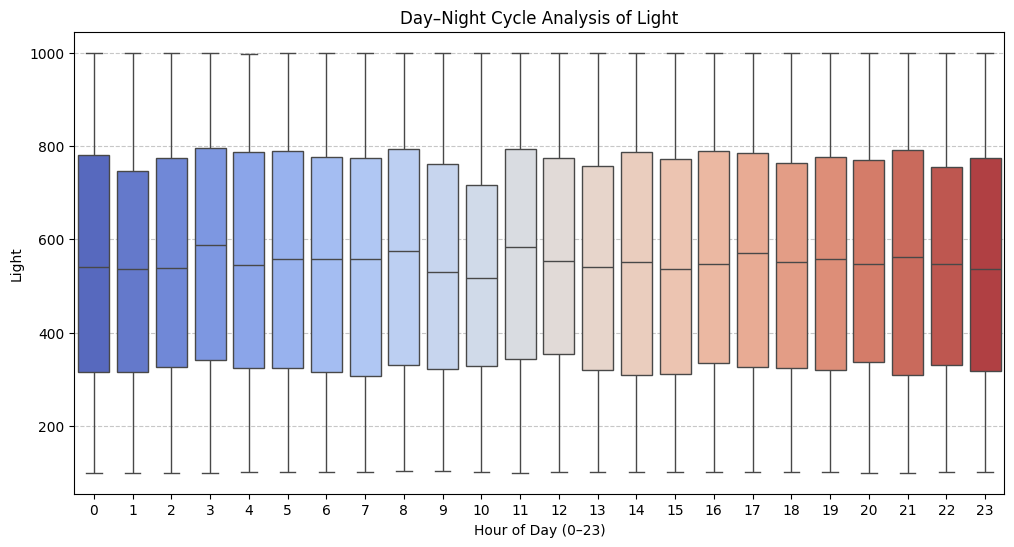

In [5]:
#1.2 Pattern Identification

#Identify day–night cycles using boxplot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])

# Extract hour of day
df["hour"] = df["timestamp"].dt.hour

# Variables to analyze
variables = ["temperature", "humidity", "light"]

# Plot boxplots for each variable
for var in variables:
    plt.figure(figsize=(12,6))
    sns.boxplot(x="hour", y=var, data=df, palette="coolwarm")
    plt.title(f"Day–Night Cycle Analysis of {var.capitalize()}")
    plt.xlabel("Hour of Day (0–23)")
    plt.ylabel(var.capitalize())
    plt.grid(True, axis="y", linestyle="--", alpha=0.7)
    plt.show()

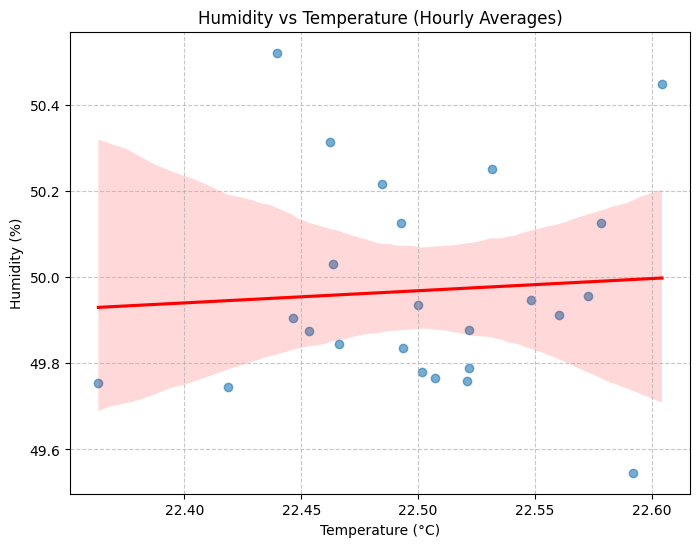

Correlation between Temperature and Humidity:
              temperature  humidity
temperature      1.00000   0.06808
humidity         0.06808   1.00000


In [6]:
#Observe humidity–temperature inverse relationships

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Scatter plot with regression line
plt.figure(figsize=(8,6))
sns.regplot(x="temperature", y="humidity", data=df_hourly, scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title("Humidity vs Temperature (Hourly Averages)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

#Correlation relationship between temperature and humidity
corr = df_hourly[["temperature", "humidity"]].corr()
print("Correlation between Temperature and Humidity:\n", corr)

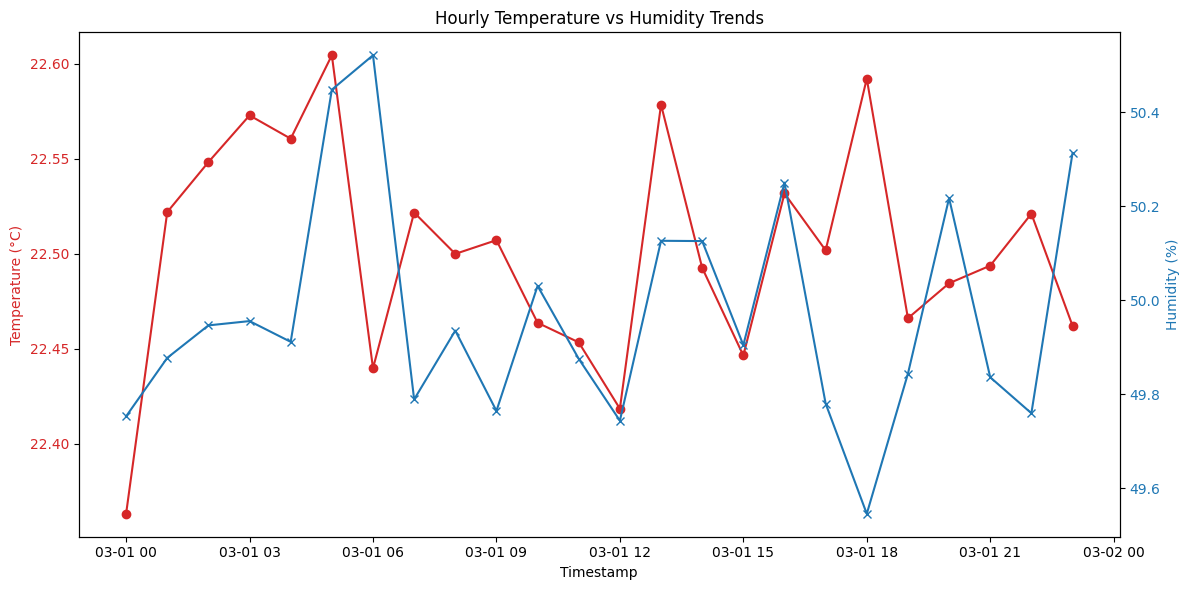

In [7]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Temperature (°C)", color="tab:red")
ax1.plot(df_hourly.index, df_hourly["temperature"], color="tab:red", marker="o", label="Temperature")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.set_ylabel("Humidity (%)", color="tab:blue")
ax2.plot(df_hourly.index, df_hourly["humidity"], color="tab:blue", marker="x", label="Humidity")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Hourly Temperature vs Humidity Trends")
fig.tight_layout()
plt.show()

In [8]:
#1.3 Basic Statistical Summaries
#Compute mean, min, max, and variance for each sensor

import pandas as pd

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Select sensor columns
sensors = ["temperature", "humidity", "light", "pH", "electrical_conductivity"]

# Compute basic statistics
stats_summary = df[sensors].agg(["mean", "min", "max", "var"])

print("Basic Statistical Summaries:\n")
print(stats_summary)

#Typical Noticed Insights
TempVsLight = "Temperature & Light - wider spread (higher variance)."
Humidity = "Humidity - inverse relationship with temperature visible in distribution."
pHVsEC = "pH & EC - narrow spread, low variance (stable sensors)."

print (f"Insightful Trend between Temperature and Light: {TempVsLight}")
print (f"Humidity and Temperature: {Humidity}")
print (f"pH and EC: {pHVsEC}")

Basic Statistical Summaries:

      temperature  humidity        light       pH  electrical_conductivity
mean     22.50191  49.96911    549.86049  7.00085                  1.24721
min      20.00000  40.00000    100.04000  6.00000                  0.50000
max      25.00000  60.00000    999.96000  8.00000                  2.00000
var       2.07679  33.19082  67778.12436  0.33265                  0.18620
Insightful Trend between Temperature and Light: Temperature & Light - wider spread (higher variance).
Humidity and Temperature: Humidity - inverse relationship with temperature visible in distribution.
pH and EC: pH & EC - narrow spread, low variance (stable sensors).


,temperature,humidity,light,pH,electrical_conductivity
mean,22.50191,49.96911,549.86049,7.00085,1.24721
min,22.36313,49.54586,526.47071,6.96994,1.22594
max,22.60447,50.52133,568.75272,7.03822,1.26958
var,0.00337,0.05811,77.40567,0.00033,0.00019


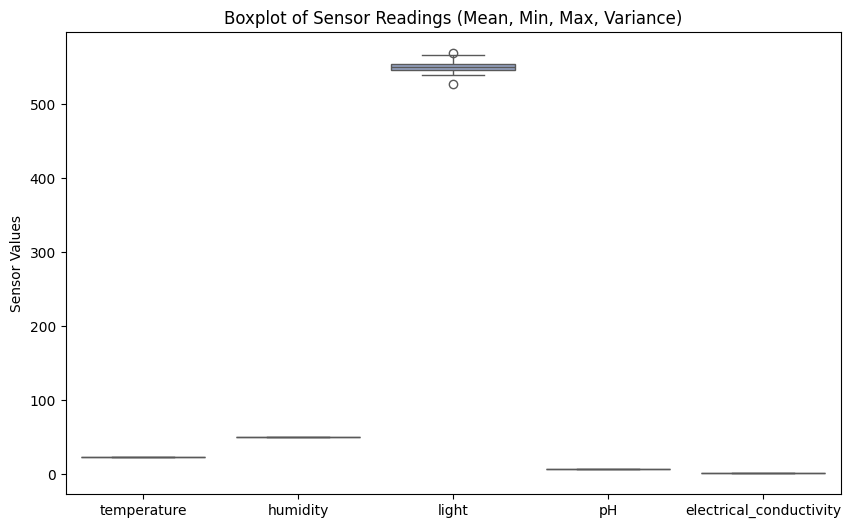

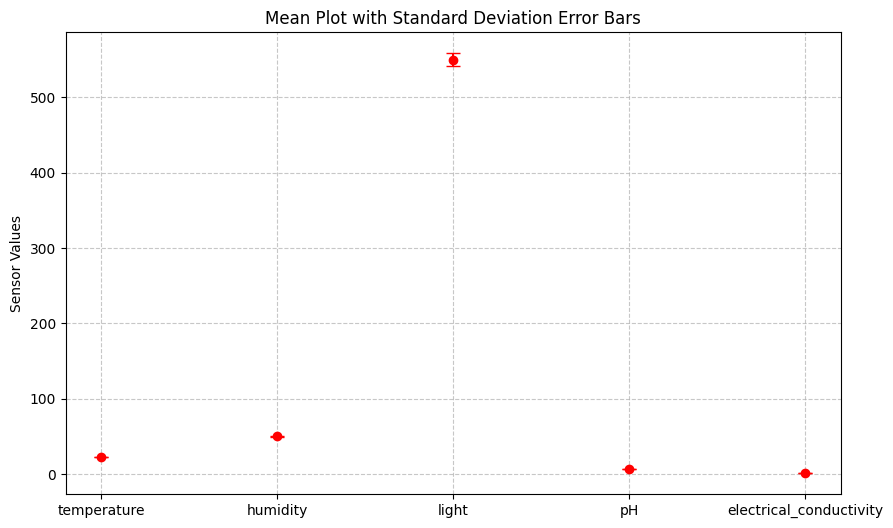

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Hourly resampling (mean)
df_hourly = df.resample("1h").mean()

# Select sensor columns
sensors = ["temperature", "humidity", "light", "pH", "electrical_conductivity"]

# Print statistical summaries in the notebook 
stats_summary = df_hourly[sensors].agg(["mean", "min", "max", "var"])
display(stats_summary)   

# Boxplot for distributions
plt.figure(figsize=(10,6))
sns.boxplot(data=df_hourly[sensors], palette="Set2")
plt.title("Boxplot of Sensor Readings (Mean, Min, Max, Variance)")
plt.ylabel("Sensor Values")
plt.show()

# Mean Plot with Error Bars (variance as std dev)
means = df_hourly[sensors].mean()
std_devs = df_hourly[sensors].std()

plt.figure(figsize=(10,6))
plt.errorbar(sensors, means, yerr=std_devs, fmt='o', capsize=5, color='red')
plt.title("Mean Plot with Standard Deviation Error Bars")
plt.ylabel("Sensor Values")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

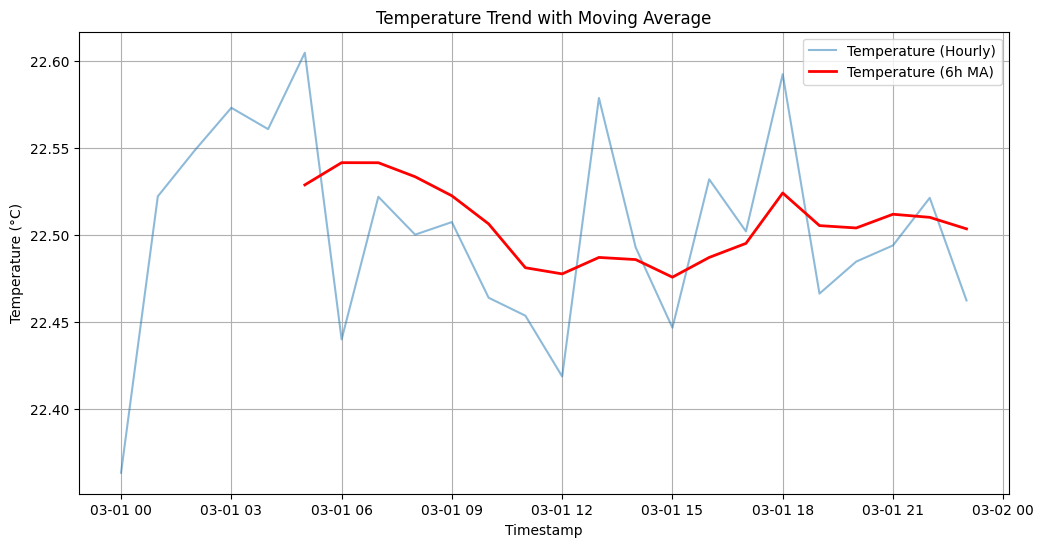

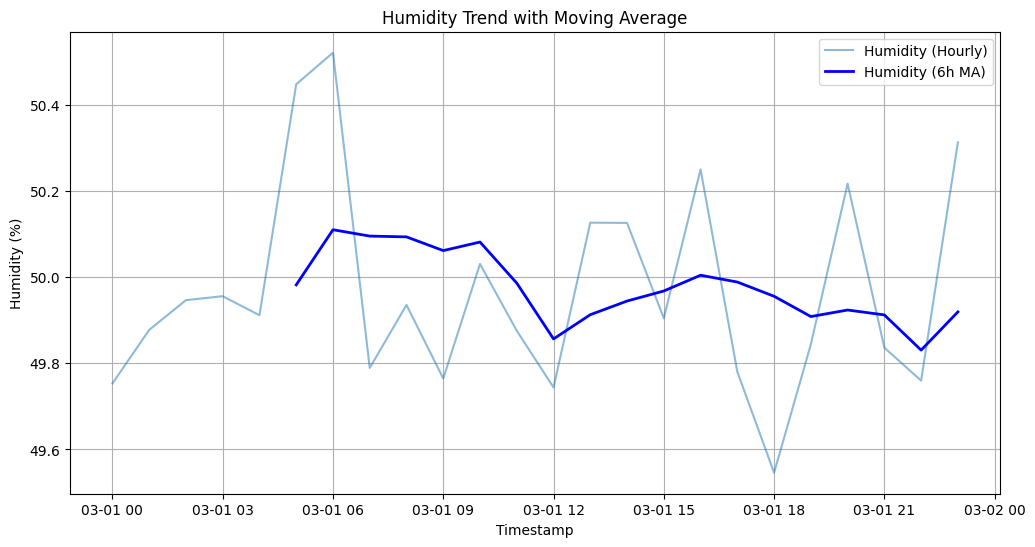

Temperature Plot: raw hourly values (fluctuating) plus a smooth red curve (moving average).
Humidity Plot: raw hourly values plus a smooth blue curve.


In [10]:
#2 Feature Engineering

#2.1 Derived Features
#Moving averages of temperature and humidity.


import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Compute moving averages (6-hour window as example)
df_hourly["temp_ma"] = df_hourly["temperature"].rolling(window=6).mean()
df_hourly["hum_ma"] = df_hourly["humidity"].rolling(window=6).mean()

# Plot Temperature with Moving Average
plt.figure(figsize=(12,6))
plt.plot(df_hourly.index, df_hourly["temperature"], alpha=0.5, label="Temperature (Hourly)")
plt.plot(df_hourly.index, df_hourly["temp_ma"], color="red", linewidth=2, label="Temperature (6h MA)")
plt.title("Temperature Trend with Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

# Plot Humidity with Moving Average
plt.figure(figsize=(12,6))
plt.plot(df_hourly.index, df_hourly["humidity"], alpha=0.5, label="Humidity (Hourly)")
plt.plot(df_hourly.index, df_hourly["hum_ma"], color="blue", linewidth=2, label="Humidity (6h MA)")
plt.title("Humidity Trend with Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

# Insightful Moving Average Trends 
TP = "raw hourly values (fluctuating) plus a smooth red curve (moving average)."
HP = "raw hourly values plus a smooth blue curve."

print (f"Temperature Plot: {TP}")
print (f"Humidity Plot: {HP}")



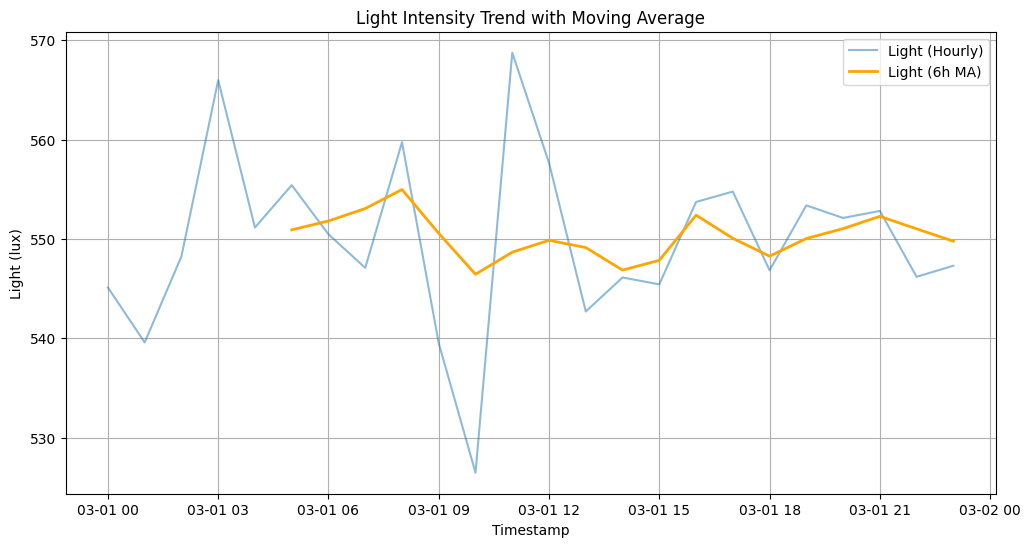

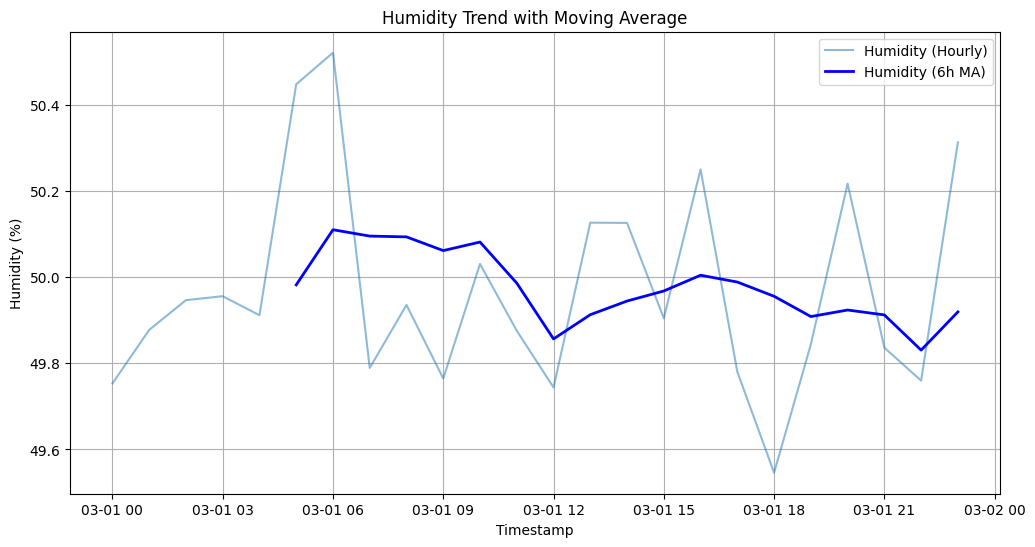

Light plot sharp spikes at sunrise/sunset smoothed into a clear daily cycle.
Humidity plot: noisy hourly values smoothed into a curve that often rises at night and dips during the day.
The moving averages make day–night cycles and inverse relationships much easier to interpret.


In [11]:
#Moving averages of light intensity and humidity.

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Compute moving averages (6-hour window as example)
df_hourly["light_ma"] = df_hourly["light"].rolling(window=6).mean()
df_hourly["hum_ma"] = df_hourly["humidity"].rolling(window=6).mean()

# --- Plot Light with Moving Average ---
plt.figure(figsize=(12,6))
plt.plot(df_hourly.index, df_hourly["light"], alpha=0.5, label="Light (Hourly)")
plt.plot(df_hourly.index, df_hourly["light_ma"], color="orange", linewidth=2, label="Light (6h MA)")
plt.title("Light Intensity Trend with Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Light (lux)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Humidity with Moving Average ---
plt.figure(figsize=(12,6))
plt.plot(df_hourly.index, df_hourly["humidity"], alpha=0.5, label="Humidity (Hourly)")
plt.plot(df_hourly.index, df_hourly["hum_ma"], color="blue", linewidth=2, label="Humidity (6h MA)")
plt.title("Humidity Trend with Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

#Insightful Trends
LP = "Light plot sharp spikes at sunrise/sunset smoothed into a clear daily cycle."
HP = "Humidity plot: noisy hourly values smoothed into a curve that often rises at night and dips during the day."
MA = "The moving averages make day–night cycles and inverse relationships much easier to interpret."

print (f"{LP}")
print (f"{HP}")
print (f"{MA}")


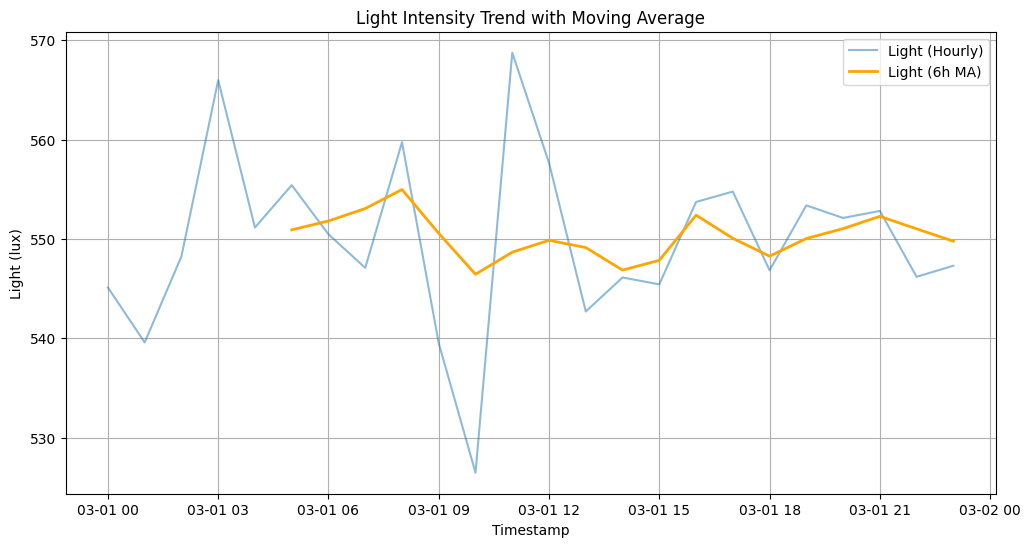

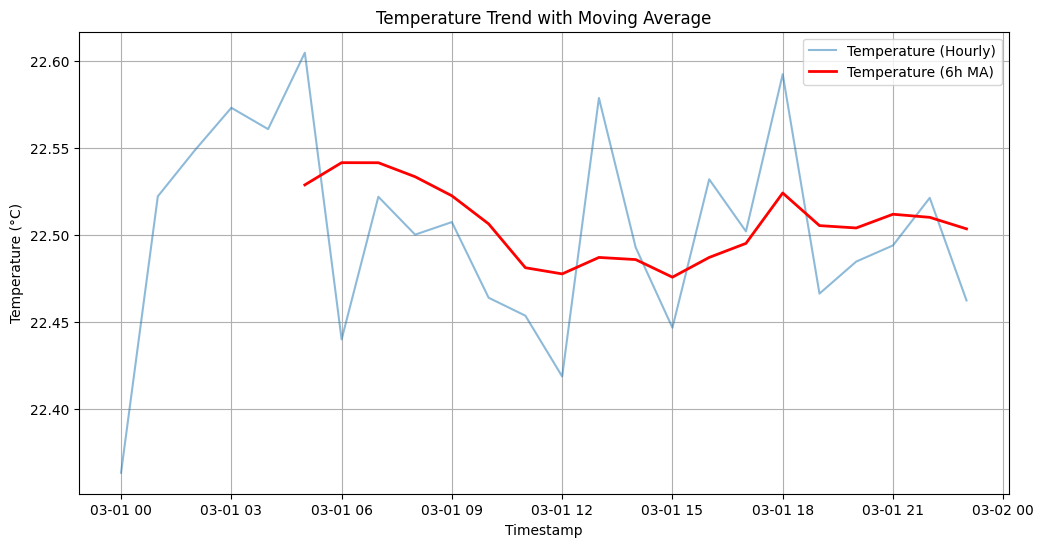

Light plot: raw hourly values (spikes at sunrise/sunset) smoothed into a clear daily cycle.
Humidity plot: noisy hourly values smoothed into a curve that often rises at night and dips during the day.
The moving averages highlight day–night cycles and show how temperature typically lags behind light intensity.


In [12]:
#Moving averages of light intensity and temperature.

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Compute moving averages (6-hour window as example)
df_hourly["light_ma"] = df_hourly["light"].rolling(window=6).mean()
df_hourly["temp_ma"] = df_hourly["temperature"].rolling(window=6).mean()

# --- Plot Light with Moving Average ---
plt.figure(figsize=(12,6))
plt.plot(df_hourly.index, df_hourly["light"], alpha=0.5, label="Light (Hourly)")
plt.plot(df_hourly.index, df_hourly["light_ma"], color="orange", linewidth=2, label="Light (6h MA)")
plt.title("Light Intensity Trend with Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Light (lux)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Temperature with Moving Average ---
plt.figure(figsize=(12,6))
plt.plot(df_hourly.index, df_hourly["temperature"], alpha=0.5, label="Temperature (Hourly)")
plt.plot(df_hourly.index, df_hourly["temp_ma"], color="red", linewidth=2, label="Temperature (6h MA)")
plt.title("Temperature Trend with Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

#Insightful Trends
LP = "Light plot: raw hourly values (spikes at sunrise/sunset) smoothed into a clear daily cycle."
TP = "Temperature plot: raw hourly values plus a smooth curve showing gradual heating and cooling."
MA = "The moving averages highlight day–night cycles and show how temperature typically lags behind light intensity."

print (f"{LP}")
print (f"{HP}")
print (f"{MA}")


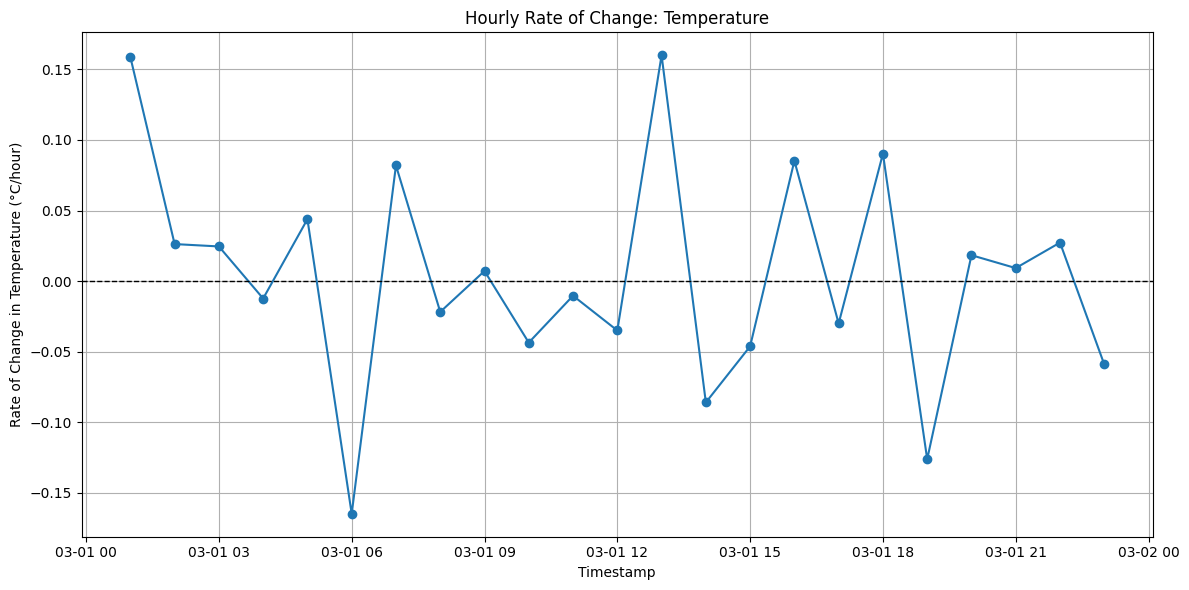

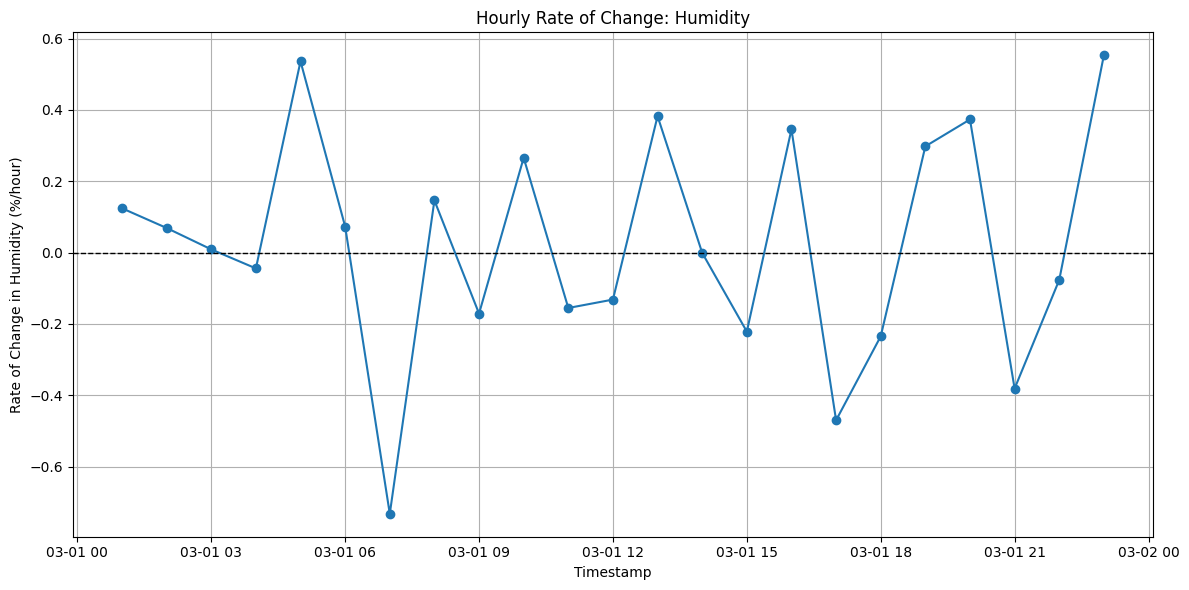

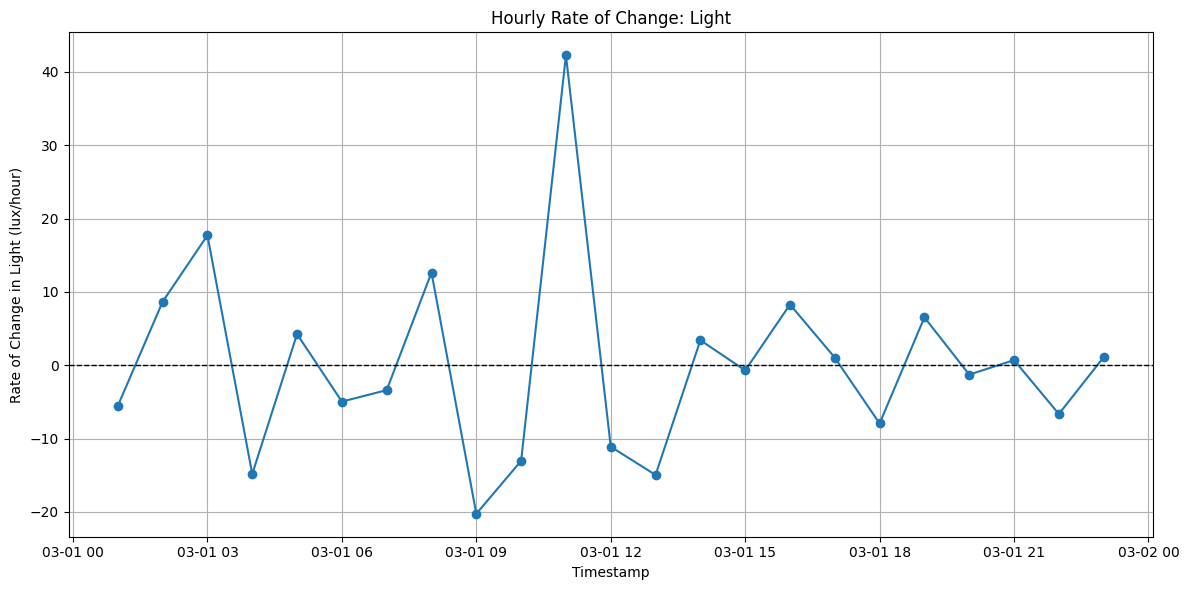

Temperature: rises quickly in the day (positive slope), then fall at night (negative slope).
Humidity: shows the opposite pattern.
Light Intensity: spikes sharply at sunrise and drops at sunset.


In [13]:
#Rate-of-change features

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Compute rate of change (first difference)
df_rate = df_hourly.diff()

# Define variables to plot
variables = {
    "temperature": "Rate of Change in Temperature (°C/hour)",
    "humidity": "Rate of Change in Humidity (%/hour)",
    "light": "Rate of Change in Light (lux/hour)"
}

# Plot each variable's rate of change
for var, ylabel in variables.items():
    plt.figure(figsize=(12,6))
    plt.plot(df_rate.index, df_rate[var], marker='o', linestyle='-')
    plt.axhline(0, color='black', linewidth=1, linestyle='--')  # baseline
    plt.title(f"Hourly Rate of Change: {var.capitalize()}")
    plt.xlabel("Timestamp")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Insightful Trends

Temperature = "rises quickly in the day (positive slope), then fall at night (negative slope)."
Humidity = "shows the opposite pattern."
Light_Intensity = "spikes sharply at sunrise and drops at sunset."

print (f"Temperature: {Temperature}")
print (f"Humidity: {Humidity}")
print (f"Light Intensity: {Light_Intensity}")


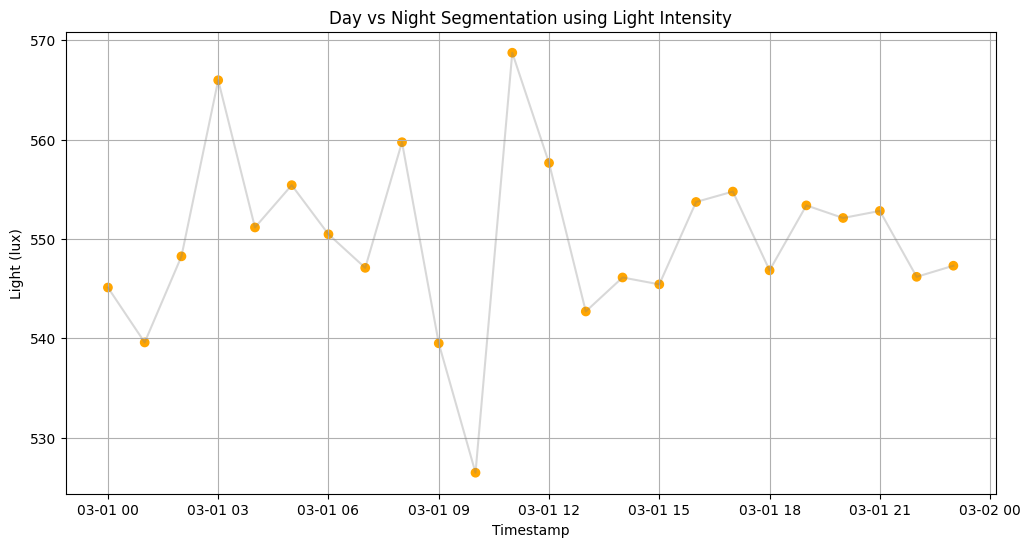

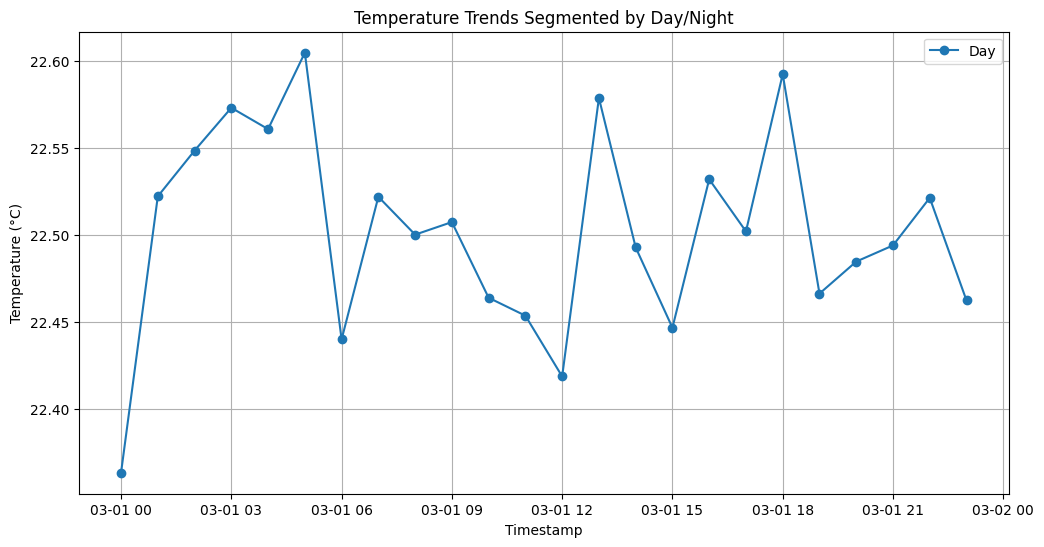

In [14]:
# 2.2 Day/Night Segmentation
#Use light intensity to label day vs night

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Define threshold for day/night segmentation
threshold = 100  # lux (adjust if needed)
df_hourly["day_night"] = df_hourly["light"].apply(lambda x: "Day" if x > threshold else "Night")

# Plot Light Intensity with Day/Night Labels
plt.figure(figsize=(12,6))
colors = df_hourly["day_night"].map({"Day":"orange", "Night":"blue"})
plt.scatter(df_hourly.index, df_hourly["light"], c=colors, label="Light Intensity")
plt.plot(df_hourly.index, df_hourly["light"], alpha=0.3, color="gray")
plt.title("Day vs Night Segmentation using Light Intensity")
plt.xlabel("Timestamp")
plt.ylabel("Light (lux)")
plt.grid(True)
plt.show()

# Overlay Temperature with Day/Night Segmentation 
plt.figure(figsize=(12,6))
for label, group in df_hourly.groupby("day_night"):
    plt.plot(group.index, group["temperature"], marker='o', linestyle='-', label=label)
plt.title("Temperature Trends Segmented by Day/Night")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10800\2113721337.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day_night", y="temperature", data=df_hourly, palette="Set2")


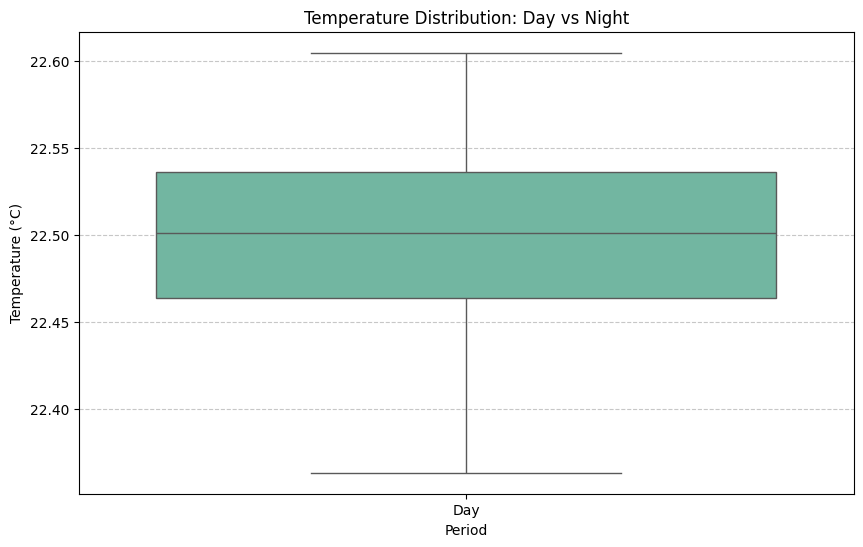

C:\Users\Admin\AppData\Local\Temp\ipykernel_10800\2113721337.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day_night", y="humidity", data=df_hourly, palette="Set2")


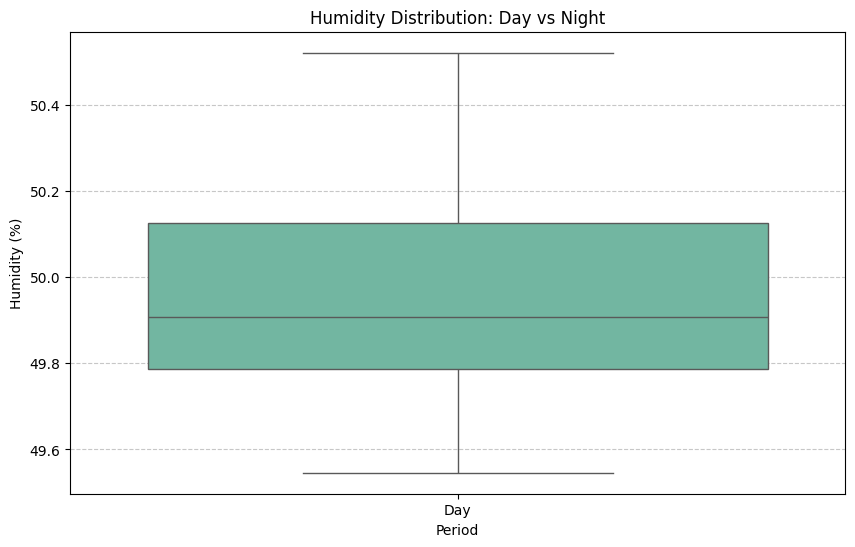

Temperature Boxplot: Daytime values generally higher, with wider spread WHILE Nighttime values lower and more stable.
Humidity Boxplot: Nighttime humidity typically higher (air holds more moisture when cooler) WHILE Daytime humidity lower, with more variability.


In [15]:
# Using Boxplot for clarity

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("sensor_data_2025-03-01.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_hourly = df.resample("1h").mean()

# Define threshold for day/night segmentation
threshold = 100  # lux
df_hourly["day_night"] = df_hourly["light"].apply(lambda x: "Day" if x > threshold else "Night")

# Boxplot for Temperature 
plt.figure(figsize=(10,6))
sns.boxplot(x="day_night", y="temperature", data=df_hourly, palette="Set2")
plt.title("Temperature Distribution: Day vs Night")
plt.xlabel("Period")
plt.ylabel("Temperature (°C)")
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()

# Boxplot for Humidity 
plt.figure(figsize=(10,6))
sns.boxplot(x="day_night", y="humidity", data=df_hourly, palette="Set2")
plt.title("Humidity Distribution: Day vs Night")
plt.xlabel("Period")
plt.ylabel("Humidity (%)")
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()

# Insightful Trends
TBP = "Temperature Boxplot: Daytime values generally higher, with wider spread WHILE Nighttime values lower and more stable."
print (f"{TBP}")
    
HBP = "Humidity Boxplot: Nighttime humidity typically higher (air holds more moisture when cooler) WHILE Daytime humidity lower, with more variability."
print (f"{HBP}")

In [16]:
#Combined Sensor Data

# Read .csv file
import pandas as pd

# Set display precision for better readability
pd.set_option('display.precision', 5)

# Load the dataset
df = pd.read_csv('combined_sensor_data.csv')

#print (df.to_string())

# Handle missing values more efficiently
if df.isnull().sum().sum() > 0:
  df = df.dropna()  # Drop only if there are missing values

# Display basic info instead of printing everything
print(df.info())  # Gives structure, column types, and missing values
print(df.head(5))  # Show first 2 rows for quick preview

<class 'pandas.DataFrame'>
RangeIndex: 120960 entries, 0 to 120959
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   timestamp                120960 non-null  str    
 1   temperature              120960 non-null  float64
 2   humidity                 120960 non-null  float64
 3   light                    120960 non-null  float64
 4   pH                       120960 non-null  float64
 5   electrical_conductivity  120960 non-null  float64
 6   source_file              120960 non-null  str    
dtypes: float64(5), str(2)
memory usage: 6.5 MB
None
             timestamp  temperature  humidity   light    pH  \
0  2025-03-01 00:00:00        24.69     52.66  118.65  6.68   
1  2025-03-01 00:00:05        21.89     50.18  801.71  7.29   
2  2025-03-01 00:00:10        23.88     48.01  682.39  7.66   
3  2025-03-01 00:00:15        20.42     56.73  146.05  7.77   
4  2025-03-01 00:00:20        20.79   

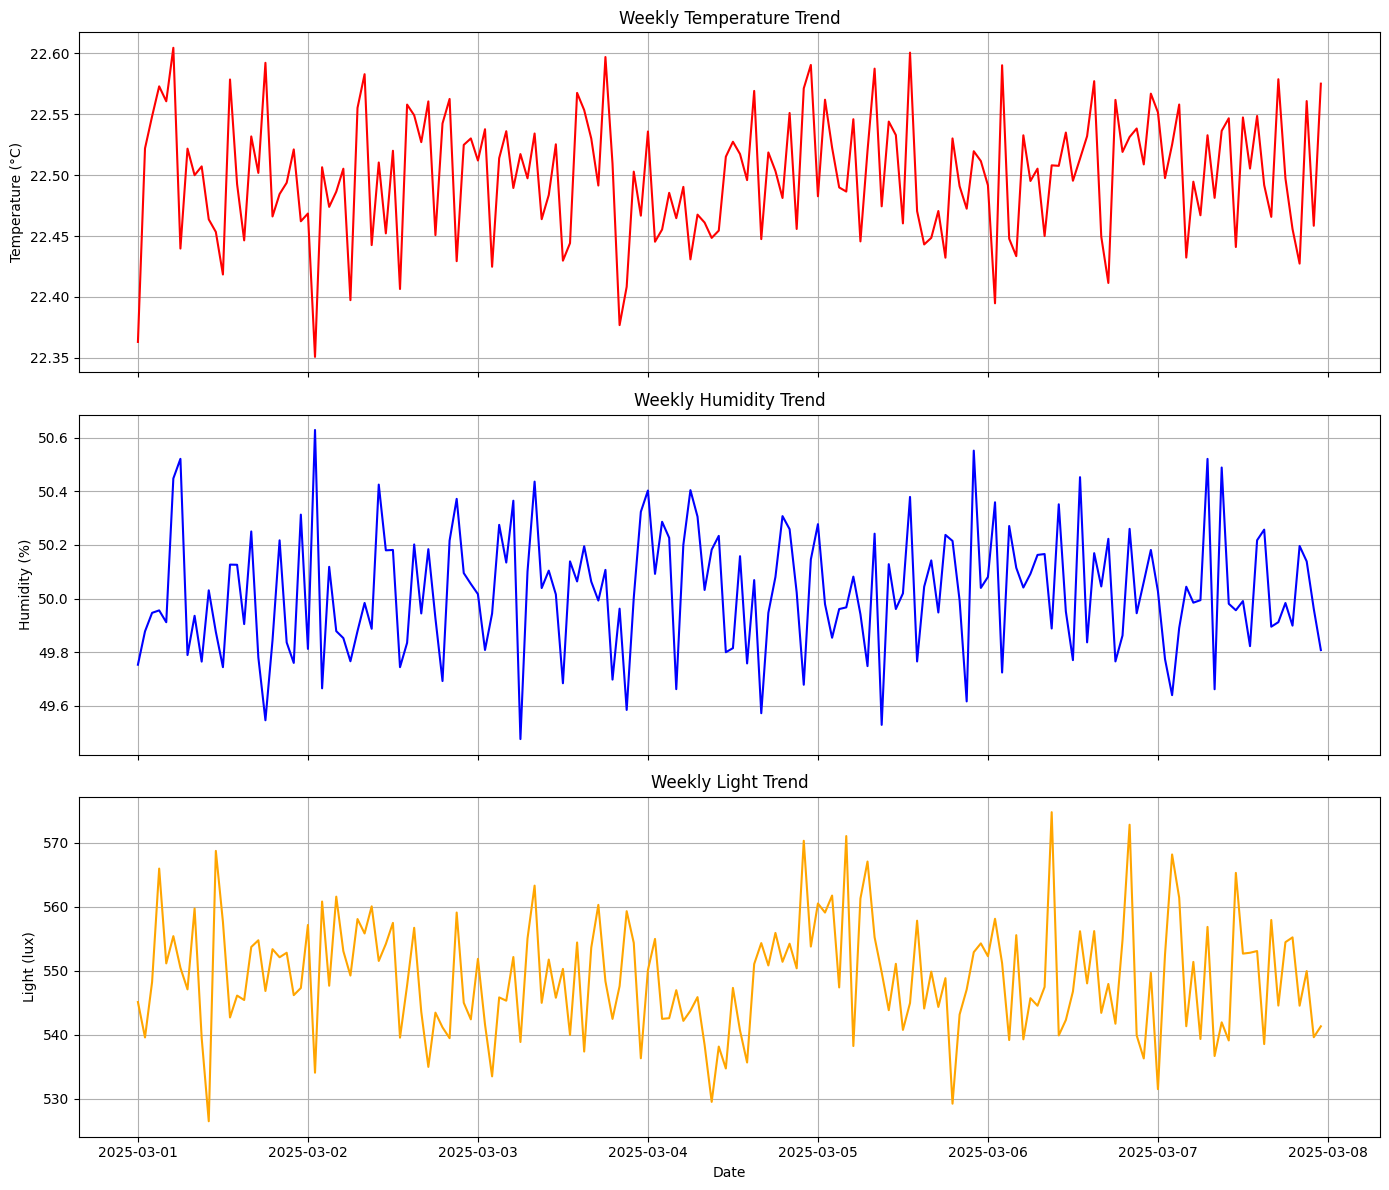

In [17]:
#1. Exploratory Data Analysis (EDA)

#1.1 Trend and Correlation Analysis
#        Plot temperature, humidity, and light trends for the whole week

import pandas as pd
import matplotlib.pyplot as plt

# List of files for the 7 days
files = [
    "sensor_data_2025-03-01.csv",
    "sensor_data_2025-03-02.csv",
    "sensor_data_2025-03-03.csv",
    "sensor_data_2025-03-04.csv",
    "sensor_data_2025-03-05.csv",
    "sensor_data_2025-03-06.csv",
    "sensor_data_2025-03-07.csv"
]

# Load and combine all files
df_list = [pd.read_csv(f, parse_dates=["timestamp"]) for f in files]
df_week = pd.concat(df_list)
df_week.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_week_hourly = df_week.resample("1h").mean()

# --- Plot weekly trends ---
fig, axes = plt.subplots(3, 1, figsize=(14,12), sharex=True)

# Temperature
axes[0].plot(df_week_hourly.index, df_week_hourly["temperature"], color="red")
axes[0].set_title("Weekly Temperature Trend")
axes[0].set_ylabel("Temperature (°C)")
axes[0].grid(True)

# Humidity
axes[1].plot(df_week_hourly.index, df_week_hourly["humidity"], color="blue")
axes[1].set_title("Weekly Humidity Trend")
axes[1].set_ylabel("Humidity (%)")
axes[1].grid(True)

# Light
axes[2].plot(df_week_hourly.index, df_week_hourly["light"], color="orange")
axes[2].set_title("Weekly Light Trend")
axes[2].set_ylabel("Light (lux)")
axes[2].grid(True)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

Weekly Correlation Matrix:
              temperature  humidity    light
temperature      1.00000   0.00077  0.07810
humidity         0.00077   1.00000 -0.09225
light            0.07810  -0.09225  1.00000


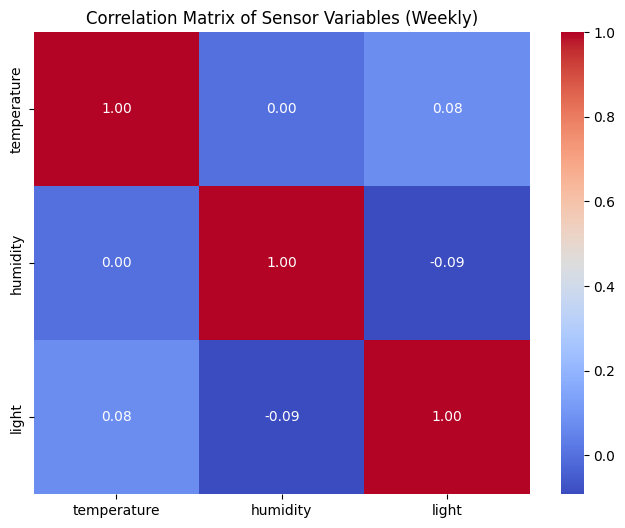

In [18]:
# Exploration of correlations among variables using correlation matrix throughout the week

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of files for the 7 days
files = [
    "sensor_data_2025-03-01.csv",
    "sensor_data_2025-03-02.csv",
    "sensor_data_2025-03-03.csv",
    "sensor_data_2025-03-04.csv",
    "sensor_data_2025-03-05.csv",
    "sensor_data_2025-03-06.csv",
    "sensor_data_2025-03-07.csv"
]

# Load and combine all files
df_list = [pd.read_csv(f, parse_dates=["timestamp"]) for f in files]
df_week = pd.concat(df_list)
df_week.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_week_hourly = df_week.resample("1h").mean()

# Compute correlation matrix
variables = ["temperature", "humidity", "light"]
corr_matrix = df_week_hourly[variables].corr()

# Display correlation matrix
print("Weekly Correlation Matrix:\n", corr_matrix)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Sensor Variables (Weekly)")
plt.show()



In [19]:
#Hottest and Brighest Day of the week

import pandas as pd

# List of files for the 7 days
files = [
    "sensor_data_2025-03-01.csv",
    "sensor_data_2025-03-02.csv",
    "sensor_data_2025-03-03.csv",
    "sensor_data_2025-03-04.csv",
    "sensor_data_2025-03-05.csv",
    "sensor_data_2025-03-06.csv",
    "sensor_data_2025-03-07.csv"
]

# Load and combine all files
df_list = [pd.read_csv(f, parse_dates=["timestamp"]) for f in files]
df_week = pd.concat(df_list)
df_week.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_week_hourly = df_week.resample("1h").mean()

# Find hottest time
hottest_time = df_week_hourly["temperature"].idxmax()
hottest_value = df_week_hourly["temperature"].max()

# Find less hot time
less_hot_time = df_week_hourly["temperature"].idxmin()
less_hot_value = df_week_hourly["temperature"].min()

# Find brightest time
brightest_time = df_week_hourly["light"].idxmax()
brightest_value = df_week_hourly["light"].max()

# Find less bright time
less_bright_time = df_week_hourly["light"].idxmin()
less_bright_value = df_week_hourly["light"].min()


print(f"Hottest time of the week: {hottest_time}, Temperature = {hottest_value:.2f} °C")
print(f"Brightest time of the week: {brightest_time}, Light = {brightest_value:.2f} lux")
print (f"Less hot time of the week: {less_hot_time}, Temperature: {less_hot_value:.2f} °C")
print (f"Less bright time of the week: {less_bright_time}, Light: {less_bright_value:.2f} lux")

Hottest time of the week: 2025-03-01 05:00:00, Temperature = 22.60 °C
Brightest time of the week: 2025-03-06 09:00:00, Light = 574.81 lux
Less hot time of the week: 2025-03-02 01:00:00, Temperature: 22.35 °C
Less bright time of the week: 2025-03-01 10:00:00, Light: 526.47 lux


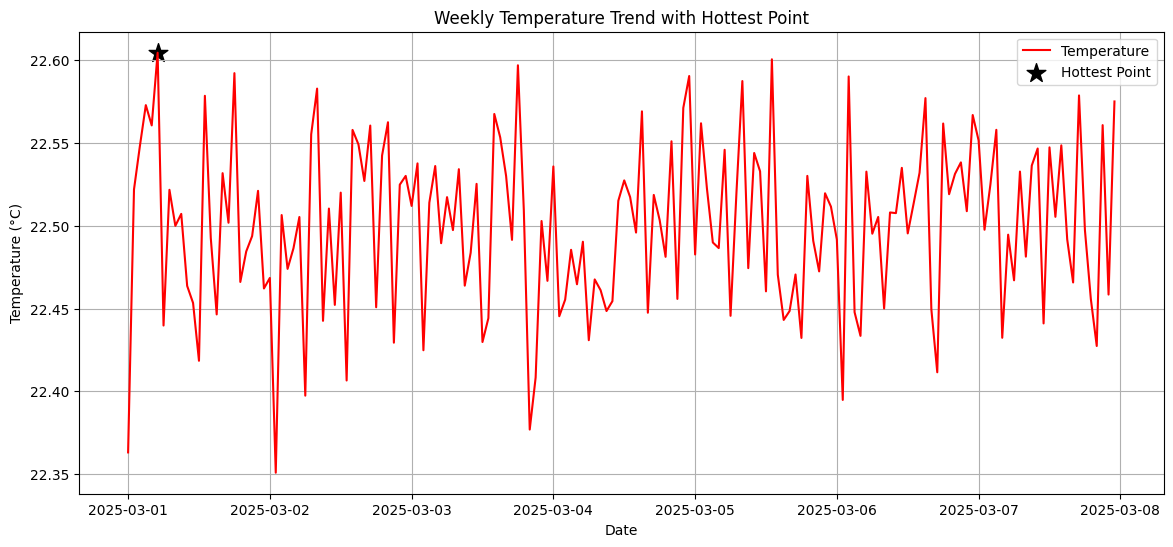

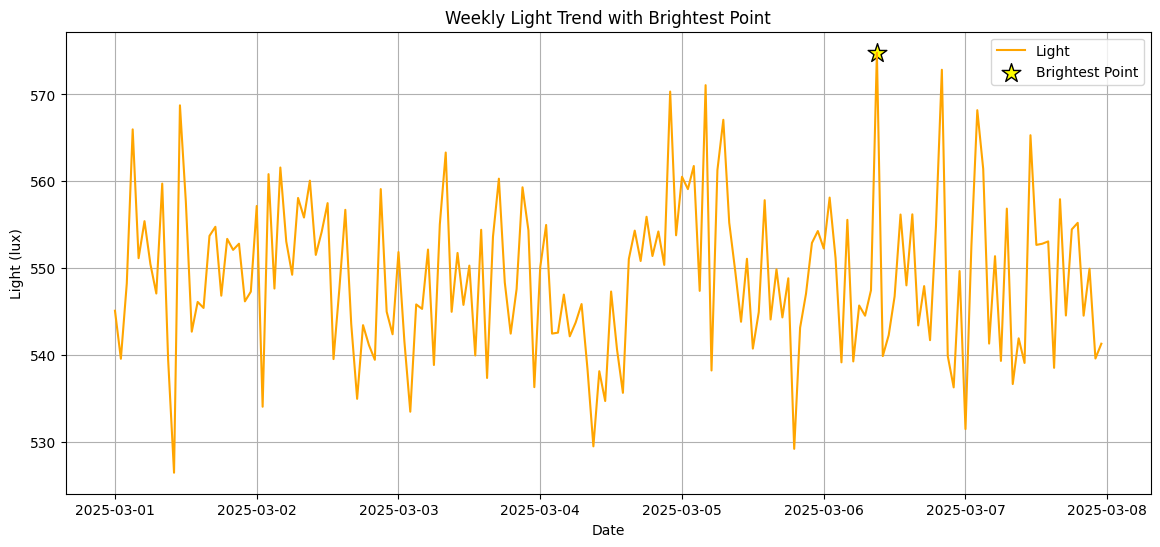

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# List of files for the 7 days
files = [
    "sensor_data_2025-03-01.csv",
    "sensor_data_2025-03-02.csv",
    "sensor_data_2025-03-03.csv",
    "sensor_data_2025-03-04.csv",
    "sensor_data_2025-03-05.csv",
    "sensor_data_2025-03-06.csv",
    "sensor_data_2025-03-07.csv"
]

# Load and combine all files
df_list = [pd.read_csv(f, parse_dates=["timestamp"]) for f in files]
df_week = pd.concat(df_list)
df_week.set_index("timestamp", inplace=True)

# Resample to hourly averages
df_week_hourly = df_week.resample("1h").mean()

# Find hottest time
hottest_time = df_week_hourly["temperature"].idxmax()
hottest_value = df_week_hourly["temperature"].max()

# Find brightest time
brightest_time = df_week_hourly["light"].idxmax()
brightest_value = df_week_hourly["light"].max()

# --- Plot Temperature Trend with Hottest Point ---
plt.figure(figsize=(14,6))
plt.plot(df_week_hourly.index, df_week_hourly["temperature"], color="red", label="Temperature")
plt.scatter(hottest_time, hottest_value, color="black", marker="*", s=200, label="Hottest Point")
plt.title("Weekly Temperature Trend with Hottest Point")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Light Trend with Brightest Point ---
plt.figure(figsize=(14,6))
plt.plot(df_week_hourly.index, df_week_hourly["light"], color="orange", label="Light")
plt.scatter(brightest_time, brightest_value, color="yellow", edgecolor="black", marker="*", s=200, label="Brightest Point")
plt.title("Weekly Light Trend with Brightest Point")
plt.xlabel("Date")
plt.ylabel("Light (lux)")
plt.legend()
plt.grid(True)
plt.show()